##KHUSHI AGGARWAL- PINN- SOC- ASSIGNMENT 1


In [ ]:
#importing all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
#for testing the accuracy of the neural network
x=np.random.uniform(-np.pi, np.pi, 100) #generating 100 random points spread evenly in the interval

def u_true(x): return np.sin(x)
def u_prime(x): return np.cos(x)
def u_doubleprime(x): return -np.sin(x)

In [ ]:
#Defining  the neural network using classes

class MyMLP(nn.Module):

  def __init__(self, hidden_size=4):
    #the size (the number of neurons in a hidden layer) is a hyperparameter that we can adjust
    super(MyMLP,self).__init__()

    #declaring the architecture of a 3-layer MLP (input-> Hidden layer-1 -> Hidden layer2-> output is the third layer)
    #both hidden layers use tanh as the activation

    self.network=nn.Sequential(
        nn.Linear(1,hidden_size),
        nn.Tanh(),
        nn.Linear(hidden_size,hidden_size),
        nn.Tanh(),
        nn.Linear(hidden_size,1),
        #nn.Tanh()
    )

  def forward(self,x):
    return self.network(x)

In [ ]:
#training the MLP with random points
# Generate 200 random points between -pi and pi
x_train_np = np.random.uniform(-np.pi, np.pi, 200)
x_train = torch.from_numpy(x_train_np).float().view(-1, 1)
y_train = torch.sin(x_train)

model = MyMLP()

#using ADAM as the optimiser
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("Training MLP to approximate sin(x) with random points...")
for epoch in range(1200): #number of iterations--> hyperparameter
    optimizer.zero_grad()
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimizer.step()
print("Training complete.\n")

Training MLP to approximate sin(x) with random points...
Training complete.



In [ ]:
#Calculating the gradients of the function that output from  the neural network using autograd.grad

x_tensor = torch.from_numpy(x).float().unsqueeze(-1).requires_grad_(True) # Convert to float32, add feature dimension, and enable gradient tracking
u=model(x_tensor)
du_dx=torch.autograd.grad(outputs=u,inputs=x_tensor,grad_outputs=torch.ones_like(u),create_graph=True)[0]
d2u_dx2=torch.autograd.grad(outputs=du_dx,inputs=x_tensor,grad_outputs=torch.ones_like(du_dx))[0]
print(f"x shape: {x_tensor.shape} | u(x) shape: {u.shape}\n")
for i in range(3):
        print(f"x: {x_tensor[i].item():.4f} | u(x): {u[i].item():.4f} | du/dx: {du_dx[i].item():.4f} | d²u/dx²: {d2u_dx2[i].item():.4f}")

x shape: torch.Size([100, 1]) | u(x) shape: torch.Size([100, 1])

x: 0.4871 | u(x): 0.4700 | du/dx: 0.9078 | d²u/dx²: -0.5017
x: -2.7298 | u(x): -0.3834 | du/dx: -0.9177 | d²u/dx²: -0.0477
x: -0.5379 | u(x): -0.5112 | du/dx: 0.8504 | d²u/dx²: 0.4835


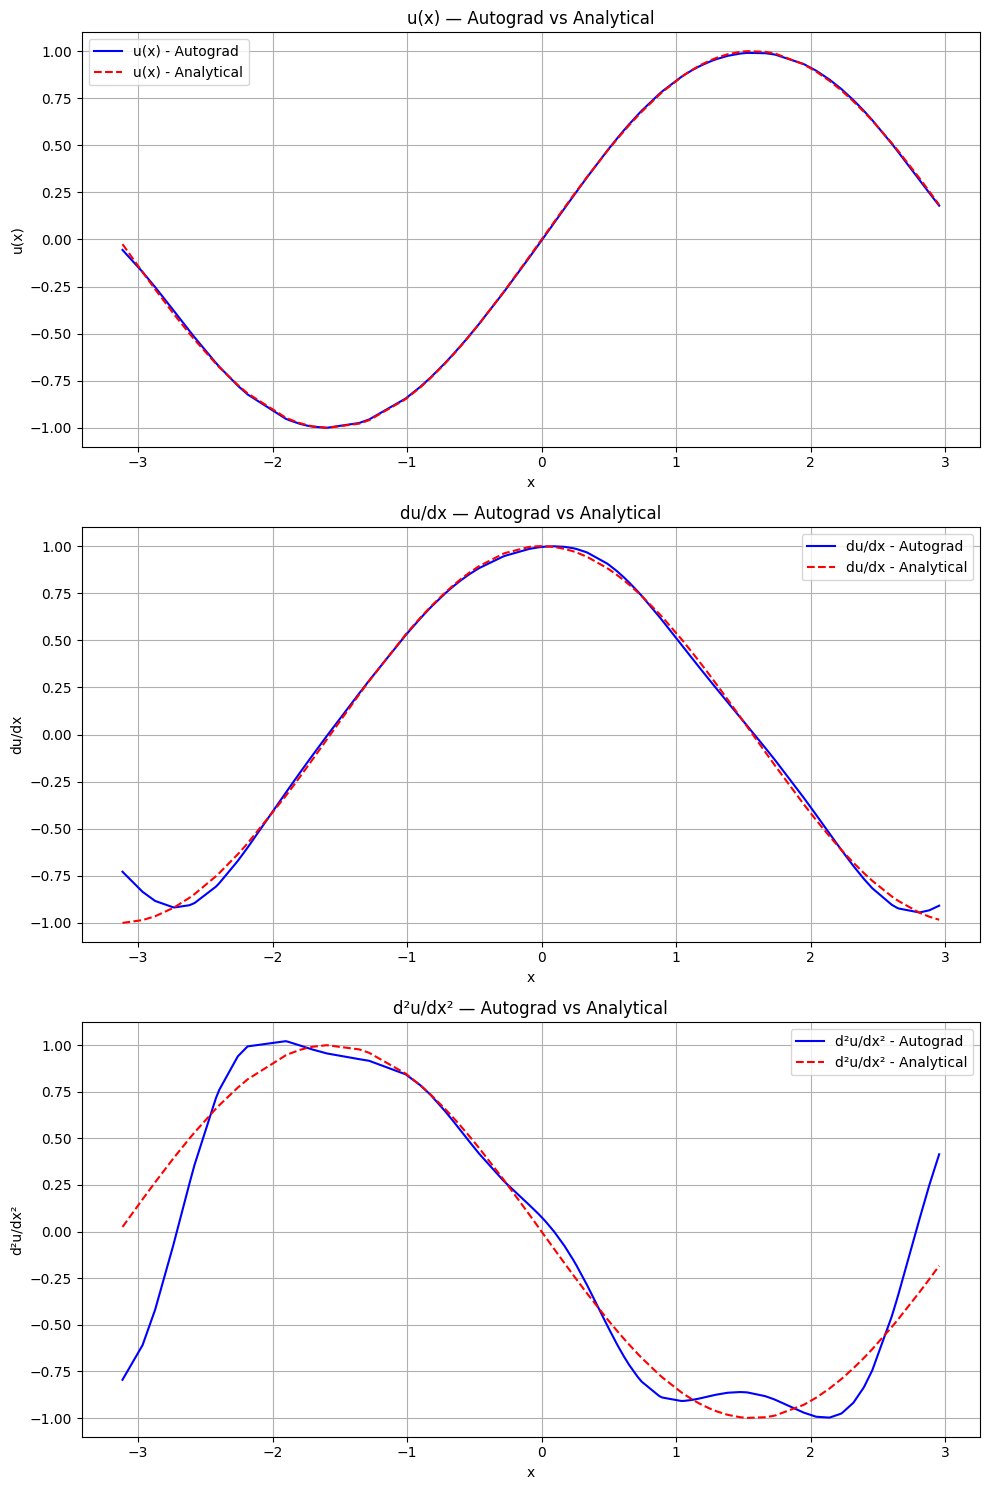

In [ ]:
#GENERATING PLOTS

import matplotlib.pyplot as plt

# Convert tensors to numpy for plotting
x_np = x_tensor.detach().numpy().flatten()
u_np = u.detach().numpy().flatten()
du_dx_np = du_dx.detach().numpy().flatten()
d2u_dx2_np = d2u_dx2.detach().numpy().flatten()

# Sort the data by x_np to ensure smooth line plots
sort_indices = np.argsort(x_np)
x_plot = x_np[sort_indices]
u_plot = u_np[sort_indices]
du_dx_plot = du_dx_np[sort_indices]
d2u_dx2_plot = d2u_dx2_np[sort_indices]

# Calculate analytical solutions using the sorted x_plot
u_analytical = u_true(x_plot)
du_dx_analytical = u_prime(x_plot)
d2u_dx2_analytical = u_doubleprime(x_plot)

# Create the figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot u(x) vs analytical u(x)
axes[0].plot(x_plot, u_plot, label='u(x) - Autograd', color='blue')
axes[0].plot(x_plot, u_analytical, label='u(x) - Analytical', color='red', linestyle='--')
axes[0].set_title('u(x) — Autograd vs Analytical')
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x)')
axes[0].legend()
axes[0].grid(True)

# Plot du/dx vs analytical du/dx
axes[1].plot(x_plot, du_dx_plot, label='du/dx - Autograd', color='blue')
axes[1].plot(x_plot, du_dx_analytical, label='du/dx - Analytical', color='red', linestyle='--')
axes[1].set_title('du/dx — Autograd vs Analytical')
axes[1].set_xlabel('x')
axes[1].set_ylabel('du/dx')
axes[1].legend()
axes[1].grid(True)

# Plot d²u/dx² vs analytical d²u/dx²
axes[2].plot(x_plot, d2u_dx2_plot, label='d²u/dx² - Autograd', color='blue')
axes[2].plot(x_plot, d2u_dx2_analytical, label='d²u/dx² - Analytical', color='red', linestyle='--')
axes[2].set_title('d²u/dx² — Autograd vs Analytical')
axes[2].set_xlabel('x')
axes[2].set_ylabel('d²u/dx²')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()